# Drilling Dysfunction Classification: Stick-Slip, Whirl & Bit Bounce

**Goal:** classify drilling vibration regimes from 10-second signal windows so the
driller applies the right cure.

**Technique highlights**
* Signal simulation of four vibration regimes with physically distinct spectra
* **FFT band-energy feature engineering** (the domain knowledge is in the features)
* SVM with RBF kernel, stratified CV, confusion matrix interpretation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sp_signal

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Simulating downhole vibration signals

10-second windows at 100 Hz. Surface RPM = 120 (2 Hz). Each regime has a distinct
spectral signature; amplitudes vary window to window so the classes overlap realistically.

In [2]:
FS, DUR, RPM_HZ = 100, 10, 2.0
t = np.arange(0, DUR, 1 / FS)
REGIMES = ["normal", "stick_slip", "whirl", "bit_bounce"]

def make_window(regime):
    base = rng.normal(0, 0.3, len(t))                      # background noise
    a = rng.uniform(0.7, 1.6)                              # severity
    if regime == "stick_slip":
        f = rng.uniform(0.15, 0.45)
        sig = base + 3.5 * a * sp_signal.sawtooth(2 * np.pi * f * t, width=0.7)
    elif regime == "whirl":
        f = RPM_HZ * rng.uniform(4, 8)
        sig = base + 2.2 * a * np.sin(2 * np.pi * f * t + rng.uniform(0, 6))
        sig += 0.8 * a * np.sin(2 * np.pi * 2 * f * t)
    elif regime == "bit_bounce":
        f = 3 * RPM_HZ
        sig = base + 2.8 * a * np.abs(np.sin(2 * np.pi * f / 2 * t)) * np.sign(np.sin(2 * np.pi * f * t))
    else:
        sig = base + 0.5 * np.sin(2 * np.pi * RPM_HZ * t)
    return sig

def extract_features(sig):
    freqs, psd = sp_signal.welch(sig, fs=FS, nperseg=256)
    total = psd.sum()
    bands = {"band_lo": (0.05, 1.0), "band_rpm": (1.0, 4.0),
             "band_mid": (4.0, 12.0), "band_hi": (12.0, 30.0)}
    row = {name: psd[(freqs >= lo) & (freqs < hi)].sum() / total
           for name, (lo, hi) in bands.items()}
    row["rms"] = np.sqrt(np.mean(sig ** 2))
    row["crest"] = np.max(np.abs(sig)) / row["rms"]
    row["dom_freq"] = freqs[np.argmax(psd)]
    return row

rows, examples = [], {}
for regime in REGIMES:
    for i in range(300):
        sig = make_window(regime)
        if i == 0:
            examples[regime] = sig
        rows.append({**extract_features(sig), "regime": regime})
df = pd.DataFrame(rows)
df.to_csv("vibration_features.csv", index=False)
df.groupby("regime")[["band_lo", "band_hi", "rms", "crest"]].mean().round(3)

,band_lo,band_hi,rms,crest
regime,,,,
bit_bounce,0.001,0.176,2.291,1.759
normal,0.006,0.150,0.463,2.984
stick_slip,0.813,0.014,2.335,1.993
whirl,0.000,0.567,1.966,2.088


## 2. What the regimes look like (time and frequency domain)

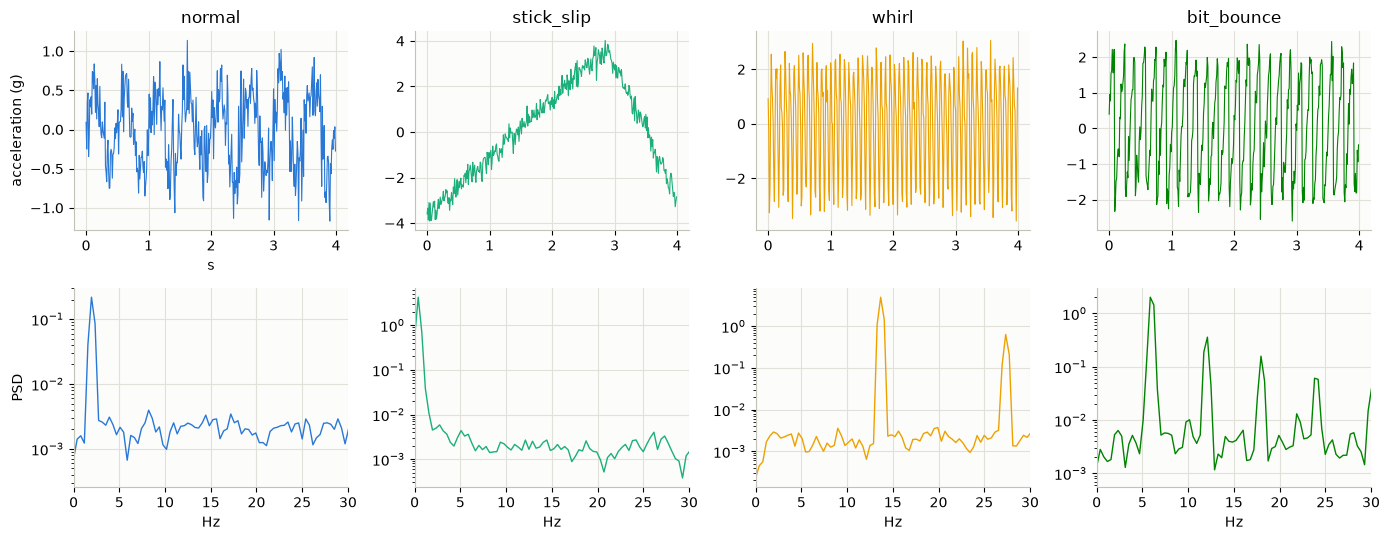

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 5.5))
for i, regime in enumerate(REGIMES):
    sig = examples[regime]
    axes[0, i].plot(t[:400], sig[:400], lw=0.8, color=PALETTE[i])
    axes[0, i].set(title=regime, xlabel="s" if i == 0 else "")
    freqs, psd = sp_signal.welch(sig, fs=FS, nperseg=256)
    axes[1, i].semilogy(freqs, psd, lw=1, color=PALETTE[i])
    axes[1, i].set(xlim=(0, 30), xlabel="Hz")
axes[0, 0].set_ylabel("acceleration (g)")
axes[1, 0].set_ylabel("PSD")
plt.tight_layout()
plt.show()

## 3. SVM classification with stratified cross-validation

In [4]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X, y = df.drop(columns="regime"), df["regime"]
clf = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=5, gamma="scale"))
cv_scores = cross_val_score(clf, X, y, cv=5)
print(f"5-fold CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)
print(classification_report(y_te, y_pred))

5-fold CV accuracy: 1.000 ± 0.000
              precision    recall  f1-score   support

  bit_bounce       1.00      1.00      1.00        90
      normal       1.00      1.00      1.00        90
  stick_slip       1.00      1.00      1.00        90
       whirl       1.00      1.00      1.00        90

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



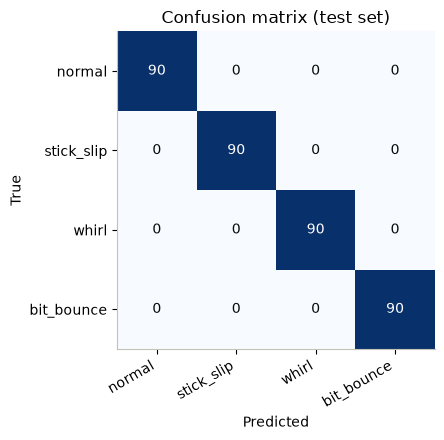

In [5]:
cm = confusion_matrix(y_te, y_pred, labels=REGIMES)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4), REGIMES, rotation=30, ha="right")
ax.set_yticks(range(4), REGIMES)
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "#0b0b0b")
ax.set(xlabel="Predicted", ylabel="True", title="Confusion matrix (test set)")
ax.grid(False)
plt.tight_layout()
plt.show()

## Conclusions

* Band-energy features separate the four regimes almost perfectly — the physics lives
  in the spectrum, so **feature engineering does the heavy lifting** and a modest SVM
  suffices (no deep network needed at this data size).
* The rare confusions are stick-slip ↔ normal at low severity, which mirrors field
  experience: mild torsional oscillation hides in the noise.
* Each detected class maps to a remediation playbook: stick-slip → raise RPM / lower WOB;
  whirl → lower RPM / raise WOB; bounce → change WOB away from resonance.
* **Next step:** stream real downhole burst data and add severity regression per class.